In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import pickle
import gzip
import urllib.request

import muon as mu
import scanpy as sc
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
mdata = mu.read("CD8_singleVDJ_emb.h5mu")
mdata = mdata[mdata.obs["source"] == "Tumor"]
mdata = mdata[mdata.obs['subtype'].isin(['CD8_Tem', 'CD8_Teff', 'CD8_Trm_exh_L', 
                              'CD8_Trm_exh_H','CD8_Trm_exh_M'])].copy()

mdata

MuData object with n_obs × n_vars = 6752 × 2500
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'tcr_embs_feature_names'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	6752 x 2500
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	6752 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [3]:
MANASCORE_DIR = r"E:\Biology\References\TCR and GEX\Ciculating T in tumor to predict response\Code\MANAscore"
models_dir = os.path.join(MANASCORE_DIR, "models")
os.makedirs(models_dir, exist_ok=True)

BASE_URL = "https://media.githubusercontent.com/media/BKI-immuno-KNS/MANAscore/main/MANAscore/models"
model_files = ["voting_i_classifier.pkl.gz", "voting_ni_classifier.pkl.gz"]

for fname in model_files:
    fpath = os.path.join(models_dir, fname)
    if not os.path.exists(fpath):
        url = f"{BASE_URL}/{fname}"
        print(f"Downloading {fname} from GitHub...")
        urllib.request.urlretrieve(url, fpath)
        print(f"  Saved to {fpath}")
    else:
        print(f"{fname} already exists locally.")

sys.path.insert(0, os.path.dirname(MANASCORE_DIR))
from MANAscore import MANAscore

scorer = MANAscore()
scorer.load_voting_models()
print("\nMANAscore models loaded successfully.")

voting_i_classifier.pkl.gz already exists locally.
voting_ni_classifier.pkl.gz already exists locally.

MANAscore models loaded successfully.


In [4]:
MANA_GENES = ["CXCL13", "ENTPD1", "IL7R"]
adata_gex = mdata["gex"]

missing = [g for g in MANA_GENES if g not in adata_gex.var_names]

if missing:
    print(f"Genes {missing} not in HVG subset ({adata_gex.n_vars} genes). Loading from full dataset...")
    full_mdata = mu.read("GSE139555_Tcells.h5mu")
    full_gex = full_mdata["gex"]
    cells = adata_gex.obs_names
    X_3g = full_gex[cells, MANA_GENES].X
    if hasattr(X_3g, "toarray"):
        X_3g = X_3g.toarray()
    gene_expr = pd.DataFrame(X_3g, index=cells, columns=MANA_GENES)
    del full_mdata, full_gex
else:
    print(f"All 3 MANAscore genes found in GEX modality.")
    X_3g = adata_gex[:, MANA_GENES].X
    if hasattr(X_3g, "toarray"):
        X_3g = X_3g.toarray()
    gene_expr = pd.DataFrame(X_3g, index=adata_gex.obs_names, columns=MANA_GENES)

gene_expr.describe()

All 3 MANAscore genes found in GEX modality.


,CXCL13,ENTPD1,IL7R
count,6752.000000,6752.000000,6752.000000
mean,0.361777,0.077605,0.426263
std,0.821137,0.260769,0.663129
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.814598
max,4.796391,2.101544,3.278288


In [5]:
# Non-imputed classifier (standard scRNA-seq without MAGIC/similar imputation)
prob_ni = scorer.voting_ni_classifier.predict_proba(gene_expr[MANA_GENES])[:, 1]
mdata["gex"].obs["MANAscore"] = prob_ni

# Imputed classifier (use if data was imputed with MAGIC etc.)
prob_i = scorer.voting_i_classifier.predict_proba(gene_expr[MANA_GENES])[:, 1]
mdata["gex"].obs["MANAscore_imputed"] = prob_i

mdata.update()

In [6]:
mdata

MuData object with n_obs × n_vars = 6752 × 2500
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'tcr_embs_feature_names'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	6752 x 2500
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status', 'MANAscore', 'MANAscore_imputed'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	6752 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

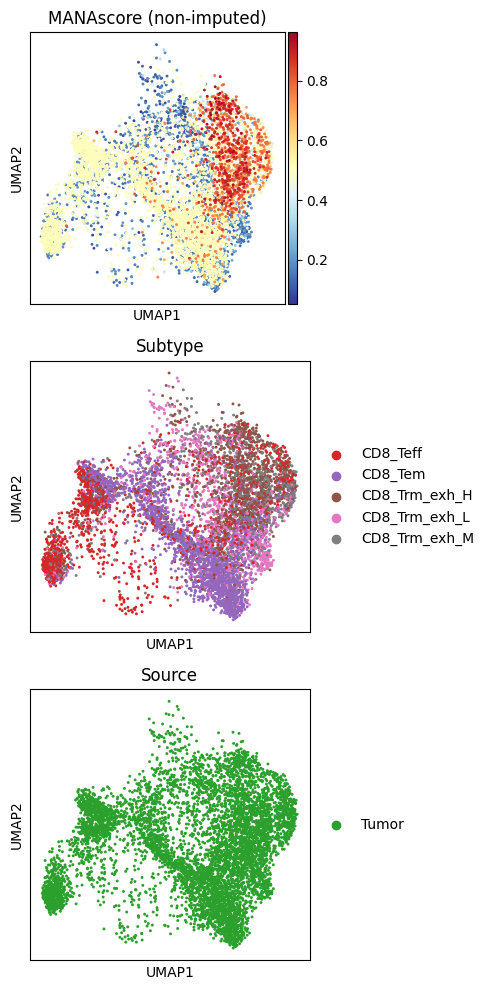

In [7]:
fig, axes = plt.subplots(3,1, figsize=(5,10))

sc.pl.umap(mdata["gex"], color="MANAscore", cmap="RdYlBu_r",
           title="MANAscore (non-imputed)", ax=axes[0], show=False)
sc.pl.umap(mdata["gex"], color="subtype",
           title="Subtype", ax=axes[1], show=False)
sc.pl.umap(mdata["gex"], color="source",
           title="Source", ax=axes[2], show=False)
plt.tight_layout()
plt.show()

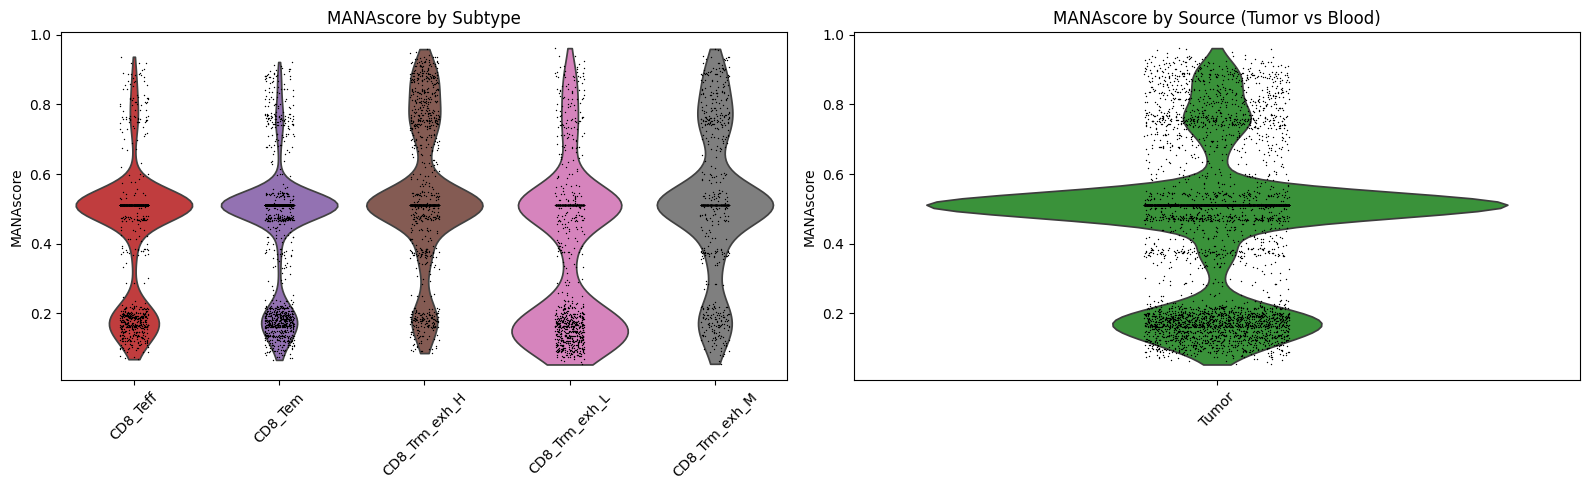

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.pl.violin(mdata["gex"], keys="MANAscore", groupby="subtype",
             rotation=45, ax=axes[0], show=False)
axes[0].set_title("MANAscore by Subtype")

sc.pl.violin(mdata["gex"], keys="MANAscore", groupby="source",
             rotation=45, ax=axes[1], show=False)
axes[1].set_title("MANAscore by Source (Tumor vs Blood)")

plt.tight_layout()
plt.show()

In [17]:
# Per-patient cutoff: MANAscore > patient-specific 90th percentile = MANAscore-hi
cutoffs = mdata['gex'].obs.groupby("patient")["MANAscore"].quantile(0.9)
mdata["gex"].obs["MANAscore_hi"] = mdata["gex"].obs.apply(
    lambda row: row["MANAscore"] > cutoffs[row["patient"]], axis=1
)

print("MANAscore-hi cells per patient:")
print(mdata['gex'].obs.groupby("patient")["MANAscore_hi"].sum().astype(int))

MANAscore-hi cells per patient:
patient
Colon1     8
Colon2     7
Endo1     86
Endo2      6
Endo3     68
Lung1     78
Lung2     60
Lung3     69
Lung4     26
Lung5     24
Lung6     31
Renal1     1
Renal2     4
Renal3     1
Name: MANAscore_hi, dtype: int64


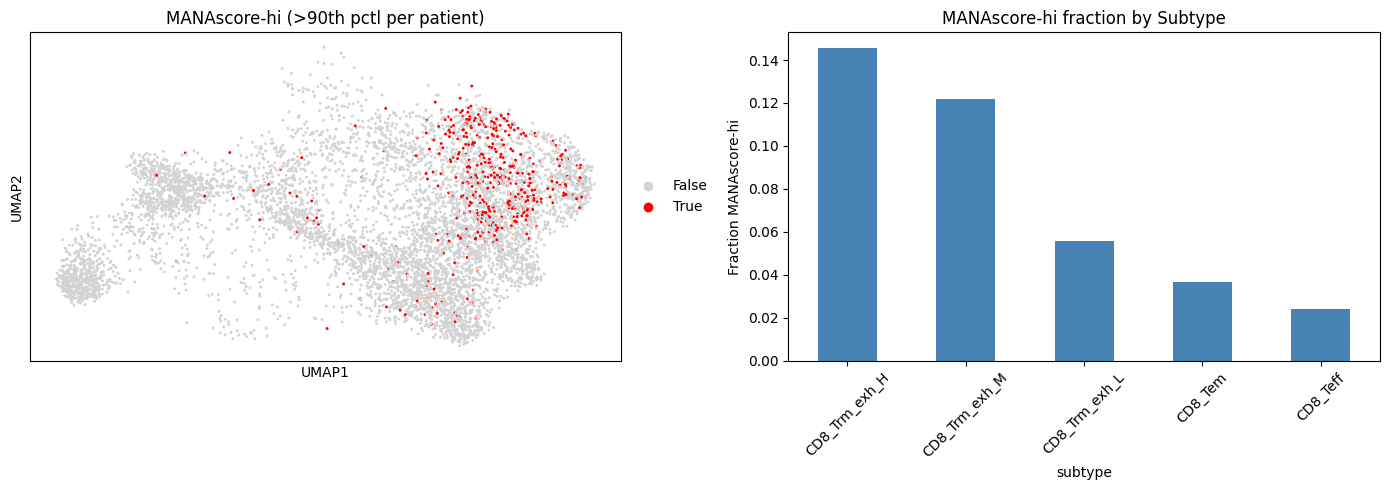

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(mdata["gex"], color="MANAscore_hi",
           title="MANAscore-hi (>90th pctl per patient)",
           palette=["lightgrey", "red"], ax=axes[0], show=False)

# Fraction MANAscore-hi per subtype
frac = mdata['gex'].obs.groupby("subtype")["MANAscore_hi"].mean().sort_values(ascending=False)
frac.plot.bar(ax=axes[1], color="steelblue")
axes[1].set_ylabel("Fraction MANAscore-hi")
axes[1].set_title("MANAscore-hi fraction by Subtype")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [20]:
mdata.write("CD8_singleVDJ_emb.h5mu")
print("Saved mdata with MANAscore columns.")

Saved mdata with MANAscore columns.
